In [255]:
# Understanding the Dataset

import pandas as pd

df = pd.read_csv("../data/netflix_stock.csv")

print(df.head())
print(df.columns)
print(df.info())
print(df.describe())




         date       open       high        low      close    volume  \
0  2014-01-02  52.401428  52.511429  51.542858  51.831429  12325600   
1  2014-01-03  52.000000  52.495712  51.842857  51.871429  10817100   
2  2014-01-06  51.889999  52.044285  50.475716  51.367142  15501500   
3  2014-01-07  49.684284  49.698570  48.152859  48.500000  36167600   
4  2014-01-08  48.104286  49.425713  48.074287  48.712856  20001100   

       rsi_7     rsi_14       cci_7      cci_14     sma_50     ema_50  \
0  34.729664  49.183584  -89.573201 -131.288579  50.112828  50.235157   
1  35.587886  49.457208  -65.820581 -103.026189  50.228771  50.299327   
2  29.820674  46.087900 -121.472559 -139.640566  50.312571  50.341203   
3  14.371863  32.522091 -206.762171 -238.029120  50.336228  50.268997   
4  18.049045  34.073549 -117.836707 -180.766801  50.373257  50.207969   

     sma_100    ema_100      macd  bollinger  TrueRange     atr_7    atr_14  \
0  46.385428  46.650698  0.751929  52.607357   1.052857

In [256]:
print(df.shape)
print(df.isnull().sum())
print(df.dtypes)

(2516, 20)
date              0
open              0
high              0
low               0
close             0
volume            0
rsi_7             0
rsi_14            0
cci_7             0
cci_14            0
sma_50            0
ema_50            0
sma_100           0
ema_100           0
macd              0
bollinger         0
TrueRange         0
atr_7             0
atr_14            0
next_day_close    0
dtype: int64
date               object
open              float64
high              float64
low               float64
close             float64
volume              int64
rsi_7             float64
rsi_14            float64
cci_7             float64
cci_14            float64
sma_50            float64
ema_50            float64
sma_100           float64
ema_100           float64
macd              float64
bollinger         float64
TrueRange         float64
atr_7             float64
atr_14            float64
next_day_close    float64
dtype: object


In [257]:
print(df["date"].head())
print(df["date"].tail())


0    2014-01-02
1    2014-01-03
2    2014-01-06
3    2014-01-07
4    2014-01-08
Name: date, dtype: object
2511    2023-12-22
2512    2023-12-26
2513    2023-12-27
2514    2023-12-28
2515    2023-12-29
Name: date, dtype: object


In [258]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date              datetime64[ns]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
rsi_7                    float64
rsi_14                   float64
cci_7                    float64
cci_14                   float64
sma_50                   float64
ema_50                   float64
sma_100                  float64
ema_100                  float64
macd                     float64
bollinger                float64
TrueRange                float64
atr_7                    float64
atr_14                   float64
next_day_close           float64
dtype: object


In [259]:
# Correlation Analysis: How strongly is each features related to tomorrow's closing price?

print(df.corr()["next_day_close"].sort_values(ascending=False))

next_day_close    1.000000
close             0.998672
low               0.998424
high              0.998388
open              0.997998
bollinger         0.990971
ema_50            0.982092
sma_50            0.977288
ema_100           0.962769
sma_100           0.949601
atr_14            0.824862
atr_7             0.795081
date              0.789802
TrueRange         0.582236
macd              0.148282
cci_14            0.030702
rsi_14            0.024001
rsi_7             0.021233
cci_7             0.020771
volume           -0.446738
Name: next_day_close, dtype: float64


In [260]:
# Features and Targets creation

X = df.drop(columns=["next_day_close", "date"])
y = df["next_day_close"]

print(X.head())
print(y.head())

        open       high        low      close    volume      rsi_7     rsi_14  \
0  52.401428  52.511429  51.542858  51.831429  12325600  34.729664  49.183584   
1  52.000000  52.495712  51.842857  51.871429  10817100  35.587886  49.457208   
2  51.889999  52.044285  50.475716  51.367142  15501500  29.820674  46.087900   
3  49.684284  49.698570  48.152859  48.500000  36167600  14.371863  32.522091   
4  48.104286  49.425713  48.074287  48.712856  20001100  18.049045  34.073549   

        cci_7      cci_14     sma_50     ema_50    sma_100    ema_100  \
0  -89.573201 -131.288579  50.112828  50.235157  46.385428  46.650698   
1  -65.820581 -103.026189  50.228771  50.299327  46.537571  46.754726   
2 -121.472559 -139.640566  50.312571  50.341203  46.680971  46.846621   
3 -206.762171 -238.029120  50.336228  50.268997  46.791957  46.879558   
4 -117.836707 -180.766801  50.373257  50.207969  46.917071  46.916075   

       macd  bollinger  TrueRange     atr_7    atr_14  
0  0.751929  52.60

In [261]:
# Creating a Random Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(2012, 18)
(504, 18)
(2012,)
(504,)


#### At this point we have 2012 training rows, 504 testing rows and 18 input features for both. We have 2012 correct target values for training and 504 correct target values for testing. Our data is now ready for the first model.

## **Linear Regression - Random Split**

In [262]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])
print(y_test.head())

[ 94.90899253 179.99090814 180.76476258 191.76534285 668.02437419]
617      95.440002
927     176.419998
942     181.350006
973     195.080002
1968    662.919983
Name: next_day_close, dtype: float64


In [263]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mse ** 0.5
r2 = r2_score(y_test, predictions)

print("MAE: ", mae)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R2: ", r2)



MAE:  5.15057857494519
MSE:  69.80523900045857
RMSE:  8.354952962193058
R2:  0.9975656145440075


##### *In random train-test splitting, observations from different time periods are mixed together. As a result, the model may be trained on data from later years while being tested on earlier years, which does not reflect how financial forecasting works in practice. Since stock prices and market conditions are highly dependent on time, the model gains indirect knowledge of patterns across the entire decade. This can lead to overly optimistic performance estimates because the model is evaluated in an environment where information from future periods influences the learning process, making the prediction task easier than it would be in a real-world forecasting scenario.*

## **Linear Regression - Time Based**

In [264]:
# Inspecting the date range

print(df["date"].min())
print(df["date"].max())

# finding the 80% cutoff point now

split_index = int(len(df)*0.8)

print(split_index)
print(df.iloc[split_index]["date"])


2014-01-02 00:00:00
2023-12-29 00:00:00
2012
2021-12-29 00:00:00


In [265]:
# creating new training and testing data using chronological order

X_train_time = X.iloc[:split_index]
X_test_time = X.iloc[split_index:]

y_train_time = y.iloc[:split_index]
y_test_time = y.iloc[split_index:]

print(X_train_time.shape)
print(X_test_time.shape)
print(y_train_time.shape)
print(y_test_time.shape)



(2012, 18)
(504, 18)
(2012,)
(504,)


In [266]:
from sklearn.linear_model import LinearRegression

time_model = LinearRegression()

time_model.fit(X_train_time, y_train_time)

time_predictions = time_model.predict(X_test_time)

In [267]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_time = mean_absolute_error(y_test_time, time_predictions)
mse_time = mean_squared_error(y_test_time, time_predictions)
rmse_time = mse_time ** 0.5
r2_time = r2_score(y_test_time, time_predictions)

print("MAE:", mae_time)
print("MSE:", mse_time)
print("RMSE:", rmse_time)
print("R2:", r2_time)

MAE: 7.701940120096861
MSE: 151.40330704501483
RMSE: 12.3046051153629
R2: 0.9832041278018684


##### Linear Regression achieved stronger performance under random train-test splitting (MAE = 5.15, RMSE = 8.35, R² = 0.9976) than under chronological time-based validation (MAE = 7.70, RMSE = 12.30, R² = 0.9832). The increase in prediction error suggests that random splitting may provide overly optimistic estimates of model performance by allowing the model to learn patterns from multiple market periods that would not be available in a real forecasting scenario.

### **Decision Tree - Random**

In [268]:
# importing decision tree

from sklearn.tree import DecisionTreeRegressor

dt_random = DecisionTreeRegressor(random_state=42)

dt_random.fit(X_train, y_train)

dt_random_predictions = dt_random.predict(X_test)

In [269]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_random = mean_absolute_error(y_test, dt_random_predictions)
mse_dt_random = mean_squared_error(y_test, dt_random_predictions)
rmse_dt_random = mse_dt_random ** 0.5
r2_dt_random = r2_score(y_test, dt_random_predictions)

print("MAE:", mae_dt_random)
print("RMSE:", rmse_dt_random)
print("R2:", r2_dt_random)


MAE: 7.829447285714284
RMSE: 12.767838034677238
R2: 0.9943149268648983


### **Decision Tree - Time Based**

In [270]:
from sklearn.tree import DecisionTreeRegressor

dt_time = DecisionTreeRegressor(random_state=42)
dt_time.fit(X_train_time, y_train_time)

dt_time_predictions = dt_time.predict(X_test_time)

In [271]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_time = mean_absolute_error(y_test_time, dt_time_predictions)
mse_dt_time = mean_squared_error(y_test_time, dt_time_predictions)
rmse_dt_time = mse_dt_time ** 0.5
r2_dt_time = r2_score(y_test_time, dt_time_predictions)

print("MAE:", mae_dt_time)
print("RMSE:", rmse_dt_time)
print("R2:", r2_dt_time)

MAE: 21.581943428571428
RMSE: 29.230835798083728
R2: 0.9052128060725255


#### At this point the data is suggesting that:

##### More flexible models may benefit more from random validation and suffer larger performance degradation under realistic time-based validation.

### **Random Forest - Random**

In [272]:
from sklearn.ensemble import RandomForestRegressor

rf_random = RandomForestRegressor(n_estimators=100, random_state=42)

rf_random.fit(X_train, y_train)

rf_random_predictions = rf_random.predict(X_test)

In [273]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf_random = mean_absolute_error(y_test, rf_random_predictions)
mse_rf_random  = mean_squared_error(y_test, rf_random_predictions)
rmse_rf_random = mse_rf_random ** 0.5
r2_rf_random = r2_score(y_test, rf_random_predictions)

print("MAE:", mae_rf_random)
print("RMSE:", rmse_rf_random)
print("R2:", r2_rf_random)

MAE: 5.68853871672618
RMSE: 9.127172519920096
R2: 0.997094814650279


### **Random Forest - Time Based**

In [274]:
rf_time = RandomForestRegressor(n_estimators = 100, random_state = 42)

rf_time.fit(X_train_time, y_train_time)

rf_time_predictions = rf_time.predict(X_test_time)

In [275]:
# Evaluation

mae_rf_time = mean_absolute_error(y_test_time, rf_time_predictions)
mse_rf_time = mean_squared_error(y_test_time, rf_time_predictions)
rmse_rf_time = mse_rf_time ** 0.5
r2_rf_time = r2_score(y_test_time, rf_time_predictions)

print("MAE:", mae_rf_time)
print("RMSE:", rmse_rf_time)
print("R2:", r2_rf_time)


MAE: 12.163230523749986
RMSE: 16.808907078768257
R2: 0.9686565965644899


## **Walk-Forward Validation or Expanding Window Validation**

In [276]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    print("TRAIN:", len(train_index))
    print("TEST:", len(test_index))
    print("----------------------")

TRAIN: 421
TEST: 419
----------------------
TRAIN: 840
TEST: 419
----------------------
TRAIN: 1259
TEST: 419
----------------------
TRAIN: 1678
TEST: 419
----------------------
TRAIN: 2097
TEST: 419
----------------------


#### **Linear Regression - Walk-Forward Validation**

In [277]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = LinearRegression()
    model.fit(X_train_fold, y_train_fold)
    
    predictions_lr_wf = model.predict(X_test_fold)
    
    mae_scores.append(mean_absolute_error(y_test_fold, predictions_lr_wf))
    
    rmse_lr_wf = mean_squared_error(
    y_test_fold,
    predictions_lr_wf
    ) ** 0.5

    print("Fold RMSE:", rmse_lr_wf)
    rmse_scores.append(rmse_lr_wf)
    
    r2_scores.append(r2_score(y_test_fold, predictions_lr_wf))
lr_fold_rmse = rmse_scores.copy()
mean_rmse_lr_wf = np.mean(rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_lr_wf)
print("Average R2:", np.mean(r2_scores))


Fold RMSE: 3.048696090837197
Fold RMSE: 7.511235866584928
Fold RMSE: 9.761128568944443
Fold RMSE: 14.22269561407822
Fold RMSE: 8.91161034891917
Average MAE: 5.897223976367825
Average RMSE: 8.69107329787279
Average R2: 0.9814383777717085


#### **Decision Tree - Walk-Forward Validation**

In [278]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []
fold = 1
for train_index, test_index in tscv.split(X):
    
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = DecisionTreeRegressor(random_state=42)
    
    model.fit(X_train_fold, y_train_fold)
    
    predictions_dt_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_dt_wf)
    )
    
    rmse_dt_wf = mean_squared_error(
        y_test_fold,
        predictions_dt_wf
    ) ** 0.5

    rmse_scores.append(rmse_dt_wf)
    print(f"Fold {fold} RMSE:", rmse_dt_wf)

    fold += 1
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_dt_wf)
    )
dt_fold_rmse = rmse_scores.copy()
mean_rmse_dt_wf = np.mean(rmse_scores)
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_dt_wf)
print("Average R2:", np.mean(r2_scores))

Fold 1 RMSE: 12.79780341542204
Fold 2 RMSE: 133.53780454188234
Fold 3 RMSE: 48.05499275635329
Fold 4 RMSE: 59.95018794620788
Fold 5 RMSE: 15.359711992339793
Average MAE: 40.62763941622911
Average RMSE: 53.94010013044107
Average R2: 0.13826235553526803


#### **Random Forest - Walk-Forward Validation**

In [279]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tscv = TimeSeriesSplit(n_splits = 5)

mae_scores = []
rmse_scores = []
r2_scores = []

for train_index, test_index in tscv.split(X):
    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]
    
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train_fold, y_train_fold)
    
    predictions_rf_wf = model.predict(X_test_fold)
    
    mae_scores.append(
        mean_absolute_error(y_test_fold, predictions_rf_wf)
        )
    rmse_rf_wf = mean_squared_error(
    y_test_fold,
    predictions_rf_wf
    ) ** 0.5

    rmse_scores.append(rmse_rf_wf)

    print("Fold RMSE:", rmse_rf_wf)
    
    r2_scores.append(
        r2_score(y_test_fold, predictions_rf_wf)
    )
rf_fold_rmse = rmse_scores.copy()
mean_rmse_rf_wf =  np.mean(rmse_scores)  
print("Average MAE:", np.mean(mae_scores))
print("Average RMSE:", mean_rmse_rf_wf)
print("Average R2:", np.mean(r2_scores))
    
    

Fold RMSE: 13.468279288286272
Fold RMSE: 133.3128855406323
Fold RMSE: 36.93914465974491
Fold RMSE: 48.923214237651806
Fold RMSE: 10.619836602521257
Average MAE: 36.2357590158616
Average RMSE: 48.652672065767305
Average R2: 0.20858516729908105


In [280]:
tscv = TimeSeriesSplit(n_splits = 5)

fold = 1

for train_index, test_index in tscv.split(X):
    train_start = df.iloc[train_index[0]]["date"]
    train_end = df.iloc[train_index[-1]]["date"]
    
    test_start = df.iloc[test_index[0]]["date"]
    test_end = df.iloc[test_index[-1]]["date"]
    
    print(f"Fold {fold}")
    print("Train:", train_start, "to", train_end)
    print("Test :", test_start, "to", test_end)
    print("---------------------")

    fold += 1


Fold 1
Train: 2014-01-02 00:00:00 to 2015-09-02 00:00:00
Test : 2015-09-03 00:00:00 to 2017-05-03 00:00:00
---------------------
Fold 2
Train: 2014-01-02 00:00:00 to 2017-05-03 00:00:00
Test : 2017-05-04 00:00:00 to 2019-01-02 00:00:00
---------------------
Fold 3
Train: 2014-01-02 00:00:00 to 2019-01-02 00:00:00
Test : 2019-01-03 00:00:00 to 2020-08-31 00:00:00
---------------------
Fold 4
Train: 2014-01-02 00:00:00 to 2020-08-31 00:00:00
Test : 2020-09-01 00:00:00 to 2022-04-29 00:00:00
---------------------
Fold 5
Train: 2014-01-02 00:00:00 to 2022-04-29 00:00:00
Test : 2022-05-02 00:00:00 to 2023-12-29 00:00:00
---------------------


###### *Fold-level analysis revealed substantial variation in model performance across different market periods. The largest prediction errors occurred during the May 2017 to January 2019 testing period, where both Decision Tree and Random Forest models produced RMSE values exceeding 133, while Linear Regression maintained an RMSE of only 7.51. This suggests that tree-based models struggled to generalize during periods of rapid stock appreciation and changing market conditions. In contrast, Linear Regression demonstrated relatively stable performance across all folds, indicating greater robustness under walk-forward validation.*

### **Visualization**

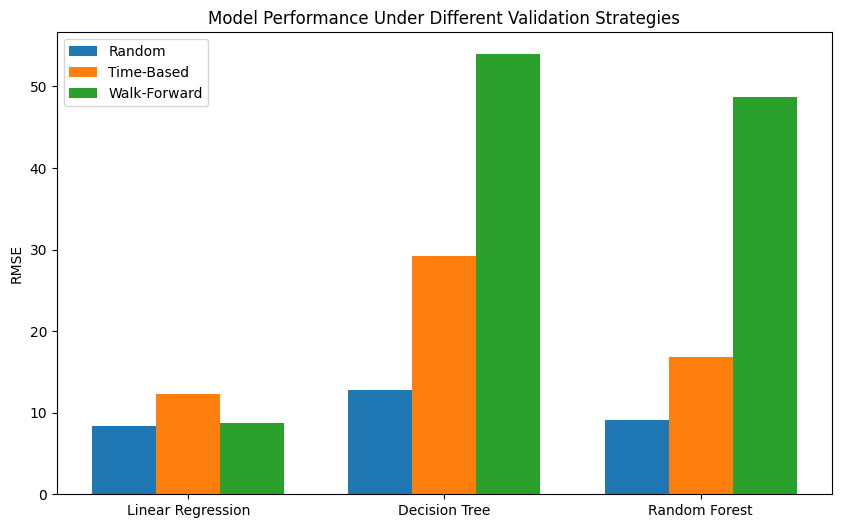

In [281]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Decision Tree", "Random Forest"]

random_rmse = [rmse, rmse_dt_random, rmse_rf_random]
time_rmse = [rmse_time, rmse_dt_time, rmse_rf_time]
walk_rmse = [float(mean_rmse_lr_wf), float(mean_rmse_dt_wf), float(mean_rmse_rf_wf)]

x = range(len(models))
width = 0.25

plt.figure(figsize = (10,6))

plt.bar([i-width for i in x], random_rmse, width=width, label = "Random" )
plt.bar(x, time_rmse, width = width, label = "Time-Based")
plt.bar([i+width for i in x], walk_rmse, width=width, label = "Walk-Forward")

plt.xticks(x, models)
plt.ylabel("RMSE")
plt.title("Model Performance Under Different Validation Strategies")
plt.legend()

plt.show()

# print(random_rmse)
# print(time_rmse)
# print(walk_rmse)

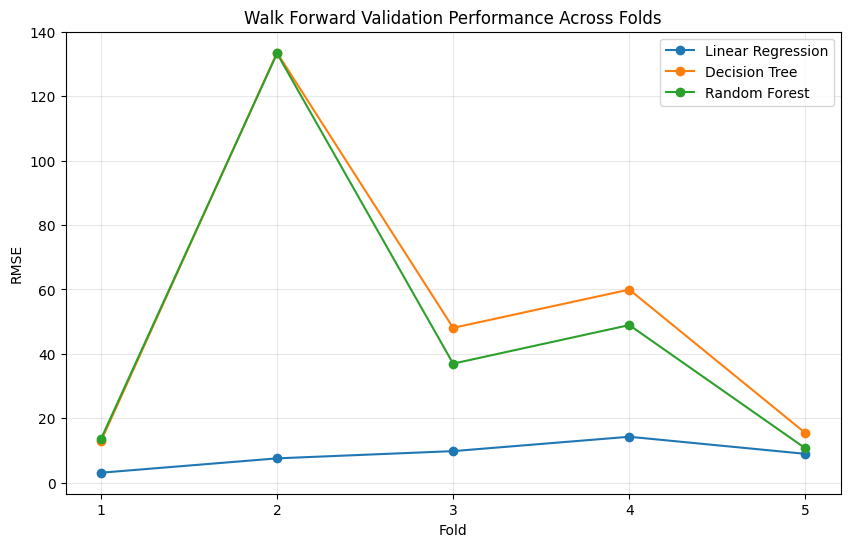

In [285]:
import matplotlib.pyplot as plt

folds = [1,2,3,4,5]

plt.figure(figsize=(10,6))

plt.plot(folds, lr_fold_rmse, marker = "o", label="Linear Regression")
plt.plot(folds, dt_fold_rmse, marker="o", label="Decision Tree")
plt.plot(folds, rf_fold_rmse, marker= "o", label="Random Forest")

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.xticks([1,2,3,4,5])
plt.grid(True, alpha = 0.3)
plt.title("Walk Forward Validation Performance Across Folds")
plt.legend()

plt.show()